# Numerical Resolution of the Malaria Transmission PDE System

This notebook presents the **numerical solver** used for the malaria transmission subsystem studied in the article. The objective is to compute reference solutions of the PDE model and analyze their qualitative behavior over the age variable $a$, the exposure variable $\xi$, and time $t$.

The notebook is part of a broader workflow that combines:
- mathematical analysis of the PDE system,
- numerical time integration.

## Numerical Modeling Principles

The numerical strategy follows the structure of the PDE system and the qualitative properties established in the theoretical analysis.

**Guiding ideas**
- The solution is expected to be smoother with respect to the exposure variable $\xi$, due to the parabolic contribution.
- The dependence on age $a$ may retain sharper structures because the age transport term does not produce the same smoothing effect.
- The numerical discretization must therefore remain consistent with the anisotropic nature of the model.

**Connection with stability analysis**
- The linear reaction structure is associated with the matrix $A_m$.
- The spectral abscissa is defined by
  $$
  \rho(A_m)=\max\{\Re(\beta):\beta\in\sigma(A_m)\}.
  $$
- The corresponding classification is:
  $$
  \rho(A_m)<0 \Rightarrow \text{exponential stability}, \qquad
  \rho(A_m)=0 \Rightarrow \text{marginal stability}, \qquad
  \rho(A_m)>0 \Rightarrow \text{instability}.
  $$

The numerical solver below is kept exactly as in the original notebook. Only the surrounding explanations and document structure are harmonized for article preparation.

## IMEX–Euler Solver Implementation

The next code cell contains the full implementation of the numerical solver used to approximate the malaria transmission subsystem. The computational pipeline, parameter choices, and exported outputs are preserved exactly as in the original notebook.

In [3]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import time
from math import ceil

# ==================== 1) PARAMETERS AND DEFINITIONS ====================

print(" MALARIA SOLVER -")
print("=" * 60)

# Fixed parameters (daily)
params_fixed = {
    "Lambda": 0.35, "phi": 0.4, "f_T": 0.5,
    "d_D": 5.0, "d_T": 5.0, "d_A": 110.0, "d_P": 25.0
}

# Diffusion/advection parameters (mu_true)
mu_true = np.array([0.005, 0.06])  # [d_exp, v_exp]
d_exp, v_exp = mu_true[0], mu_true[1]

print(f" Transmission parameters:")
print(f"  d_exp (diffusion) = {d_exp:.3f}")
print(f"  v_exp (advection) = {v_exp:.3f}")

# -----------------------------
# Reaction matrix A_m
# -----------------------------
def get_A_m(p):
    """Builds the coupling matrix A_m"""
    Λ, φ, fT = p["Lambda"], p["phi"], p["f_T"]
    d_D, d_T, d_A, d_P = p["d_D"], p["d_T"], p["d_A"], p["d_P"]
    return np.array([
        [-Λ,              0,     0,        1/d_A,     1/d_P],
        [φ*(1-fT)*Λ,   -1/d_D,   0,     φ*(1-fT)*Λ,     0   ],
        [φ*fT*Λ,          0,   -1/d_T,  φ*fT*Λ,         0   ],
        [(1-φ)*Λ,       1/d_D,   0,  -(φ*Λ + 1/d_A),    0   ],
        [0,               0,    1/d_T,      0,        -1/d_P]
    ], dtype=float)

A_true = get_A_m(params_fixed)
print("Reaction matrix A_m successfully built")

# ==================== 2) SPACE-TIME DISCRETIZATION ====================

# Domain parameters
a_max_years = 80.0
days_per_year = 365.0
a_max = a_max_years * days_per_year
L_xi = 10.0

print(f"\n Simulation domain:")
print(f"  Age: 0-{a_max_years} years ({a_max:.0f} days)")
print(f"  Exposure ξ: 0-{L_xi}")

# Grid
N_a = 100     # age intervals
N_xi = 120    # points in ξ
Na_pts = N_a + 1
Nx = N_xi

da = a_max / N_a
dx = L_xi / N_xi

# Time step computation based on CFL
CFL_age = da
CFL_xi = dx/abs(v_exp) if abs(v_exp) > 1e-12 else np.inf
CFL_diff = dx**2 / (2*d_exp) if d_exp > 0 else np.inf
dt_candidate =  0.5 * min(CFL_age, CFL_xi) # Since we use an IMEX scheme, diffusion is treated implicitly
# Avoid excessively small time steps
dt_min = 1e-4  # reasonable minimum time step (0.0001 day)
dt_reco = max(dt_candidate, dt_min)

print(f"\n Discretization:")
print(f"  Age points: {Na_pts}, Spatial points: {Nx}")
print(f"  da = {da:.2f} days, dξ = {dx:.4f}")
print(f"  Recommended dt = {dt_reco:.2e} days (CFL age: {CFL_age:.1e}, ξ: {CFL_xi:.1e}, diff: {CFL_diff:.1e})")

# Time domain
Tfinal_days = 2 * days_per_year  # 2 years of simulation
dt = dt_reco
Nt = int(np.ceil(Tfinal_days / dt))

print(f"  Time step: dt = {dt:.3e} days")
print(f"  Number of steps: Nt = {Nt}")
print(f"  Final time: T = {Tfinal_days} days ({Tfinal_days/days_per_year:.1f} years)")

# Meshes
age_grid = np.linspace(0, a_max, Na_pts)
xi_grid  = np.linspace(0, L_xi, Nx)
time_grid = np.linspace(0, Tfinal_days, Nt+1)

# ==================== 3) DEFINITION OF THE PHI AND BIRTH FUNCTIONS ====================

def phi_ic(a, xi):
    """
    Initial population distribution U(0,a,ξ)
    Adapted to work directly in days (no conversion in years in the input)
    """
    # a is in days, convert to years for the profile
    a_years = a / days_per_year

    # Age profile: exponential decay
    age_profile = np.exp(-0.03 * a_years) + 0.1 * np.exp(-0.005 * a_years)

    # Spatial profile: cosinusoidal variation
    spatial_profile = 1.0 + 0.3 * np.cos(2 * np.pi * xi / L_xi)

    # Susceptible: baseline distribution
    S0 = 200.0 * age_profile * spatial_profile

    # Asymptomatic: concentrated among young adults (peak around 25 years)
    A0 = 10.0 * np.exp(-0.5 * ((a_years - 25)/10)**2) * np.exp(-2 * (xi - L_xi/2)**2)

    return np.stack([S0, np.zeros_like(S0), np.zeros_like(S0), A0, np.zeros_like(S0)], axis=-1)

def b(t):
    """
    Human birth rate as a function of time
    t in days
    """
    return 15.0 * (1.0 + 0.1 * np.sin(2 * np.pi * t / 30.0))  # Monthly variation

print(" phi_ic and birth functions defined")

# ==================== 4) OPERATOR CONSTRUCTION ====================

def build_D_xi_first(Nx, dx, v):
    """First derivative operator in ξ (upwind scheme)"""
    if v >= 0:
        main = np.ones(Nx) * (1.0/dx)
        off = np.ones(Nx-1) * (-1.0/dx)
        D = sp.diags([main, off], [0, -1], shape=(Nx, Nx), format="csc")
        D[0,:] = 0  # Neumann condition
    else:
        main = np.ones(Nx) * (-1.0/dx)
        off = np.ones(Nx-1) * (1.0/dx)
        D = sp.diags([main, off], [0, 1], shape=(Nx, Nx), format="csc")
        D[-1,:] = 0  # Neumann condition
    return D

def build_D_xi_xixi(Nx, dx):
    """Second derivative operator in ξ (centered finite differences)"""
    main = np.ones(Nx) * (-2.0/dx**2)
    off = np.ones(Nx-1) * (1.0/dx**2)
    D2 = sp.diags([main, off, off], [0, -1, 1], shape=(Nx,Nx), format="csc")
    if Nx >= 2:
        # Neumann conditions
        D2[0,0], D2[0,1] = -2.0/dx**2, 2.0/dx**2
        D2[-1,-1], D2[-1,-2] = -2.0/dx**2, 2.0/dx**2
    return D2

def build_D_a_upwind(Na_pts, da):
    """Age transport operator (upwind scheme)"""
    N = Na_pts
    mat = sp.lil_matrix((N,N))
    for i in range(1,N):
        mat[i,i] = 1.0/da
        mat[i,i-1] = -1.0/da
    return mat.tocsc()

print("\n Building operators...")

# Differential operators
D_xi = build_D_xi_first(Nx, dx, v_exp)
D_xixi = build_D_xi_xixi(Nx, dx)
D_a = build_D_a_upwind(Na_pts, da)

# Identity operators
I_Na = sp.eye(Na_pts, format='csc')
I_5 = sp.eye(5, format='csc')
I_Nx = sp.eye(Nx, format='csc')

# Construction using Kronecker products
A_imp = sp.kron(I_Na, sp.kron(I_5, d_exp * D_xixi, format='csc'), format='csc')
A_adv = sp.kron(I_Na, sp.kron(I_5, (-v_exp) * D_xi, format='csc'), format='csc')
A_reac = sp.kron(I_Na, sp.kron(sp.csc_matrix(A_true), I_Nx, format='csc'), format='csc')
A_trans = sp.kron(D_a, sp.eye(5 * Nx, format='csc'), format='csc')

# Full explicit operator
E = (- A_trans) + (- A_adv) + A_reac

# Preparation of the implicit part
dim_global = Na_pts * 5 * Nx
I_global = sp.eye(dim_global, format='csc')
M_age = sp.eye(5*Nx, format='csc') - dt * sp.kron(I_5, d_exp * D_xixi, format='csc')
M_age = M_age.tocsc()

print(" LU factorization of the implicit matrix...")
start_factor = time.time()
LU_age = spla.splu(M_age)
print(f" Factorization completed ({time.time() - start_factor:.2f}s)")

# ==================== 5) AUXILIARY FUNCTIONS ====================

def pack_U_blocks(U_age_list):
    """Assembles age blocks into a global vector"""
    return np.concatenate(U_age_list, axis=0)

def unpack_U_global(U_global):
    """Splits the global vector into age blocks"""
    return [U_global[i*5*Nx:(i+1)*5*Nx] for i in range(Na_pts)]

def pack_cell_from_array(U3):
    """Converts a 3D array (Na_pts, Nx, 5) into a global vector"""
    if U3.shape == (Na_pts, Nx, 5):
        out_blocks = []
        for i in range(Na_pts):
            block = []
            for comp in range(5):
                block.append(U3[i,:,comp].reshape(Nx))
            out_blocks.append(np.concatenate(block))
        return pack_U_blocks(out_blocks)
    else:
        raise ValueError("Expected shape: (Na,Nx,5)")

def unpack_to_array(U_global):
    """Converts the global vector into a 3D array (Na_pts, Nx, 5)"""
    arr = np.zeros((Na_pts, Nx, 5))
    blocks = unpack_U_global(U_global)
    for i, b in enumerate(blocks):
        for comp in range(5):
            arr[i,:,comp] = b[comp*Nx:(comp+1)*Nx]
    return arr

def B_inflow(t):
    """Boundary condition at a=0 (birth inflow)"""
    xi = np.linspace(0, L_xi - dx, Nx) + dx/2
    S0 = b(t) * np.ones_like(xi)  # Using the birth function
    comps = np.zeros((5, Nx))
    comps[0,:] = S0  # Only susceptible individuals are born
    return comps

# ==================== 6) INITIAL CONDITIONS ====================

print("\n Initializing conditions...")

# Initialization of the 3D array
U0_array = np.zeros((Na_pts, Nx, 5))
for i, a in enumerate(age_grid):
    for j, xi in enumerate(xi_grid):
        U0_array[i, j, :] = phi_ic(a, xi)

# Conversion into a global vector
U_global = pack_cell_from_array(U0_array)

# Application of the initial boundary condition
U_global[0:5*Nx] = B_inflow(0.0).reshape(5*Nx)

print(" Initial and boundary conditions defined")

# ==================== 7) IMEX-EULER SCHEME ====================

def step_IMEX_Euler(U_global, t_n, dt):
    """
    One step of the IMEX-Euler scheme
    - Explicit: age transport + advection + reactions
    - Implicit: diffusion in ξ
    """
    # Explicit step
    RHS = (I_global + dt * E).dot(U_global)

    # Apply the boundary condition at a=0
    b0 = B_inflow(t_n + dt).reshape(5*Nx)
    RHS[0:5*Nx] = b0.copy()

    # Implicit resolution age block by age block
    Unew_blocks = [RHS[0:5*Nx].copy()]  # a=0 (boundary condition)

    for i in range(1, Na_pts):
        bi = RHS[i*5*Nx:(i+1)*5*Nx]
        ui_next = LU_age.solve(bi)
        Unew_blocks.append(ui_next)

    return pack_U_blocks(Unew_blocks)

# ==================== 8) TIME LOOP WITH SAVING ====================

print("\n Starting simulation...")
print("=" * 50)

# Saving parameters
save_stride = 10  # Save every n steps
U = U_global.copy()

# Snapshot storage
snapshots = []
times_saved = []

# Initialization
snapshots.append(unpack_to_array(U).astype(np.float32))
times_saved.append(0.0)

print_every = max(1, Nt // 10)
start_time = time.time()

for n in range(Nt):
    t_n = n * dt
    U = step_IMEX_Euler(U, t_n, dt)

    # Periodic saving
    if (n + 1) % save_stride == 0 or n == Nt - 1:
        arr = unpack_to_array(U).astype(np.float32)
        snapshots.append(arr)
        times_saved.append(t_n + dt)

    # Progress
    if (n + 1) % print_every == 0 or n == 0 or n == Nt - 1:
        progress = 100 * (n + 1) / Nt
        print(f"  Step {n+1}/{Nt}, t = {(n+1)*dt/days_per_year:.3f} years ({progress:.0f}%)")

simulation_time = time.time() - start_time
print(f" Simulation completed in {simulation_time:.2f}s")

# Convert to numpy arrays
snapshots = np.array(snapshots, dtype=np.float32)
times_saved = np.array(times_saved)

print(f"\n Generated snapshots: {snapshots.shape}")

# ==================== 9) SAVING RESULTS ====================

print("\n Saving results...")

np.savez_compressed(
    "malaria_simulation_results.npz",
    U_snaps=snapshots,      # Shape: (n_snapshots, Na_pts, Nx, 5)
    times=times_saved,      # Shape: (n_snapshots,)
    age_grid=age_grid,      # Shape: (Na_pts,)
    xi_grid=xi_grid,        # Shape: (Nx,)
    dt=dt,
    Na_pts=Na_pts,
    Nx=Nx,
    save_stride=save_stride,
    parameters=params_fixed,
    mu_true=mu_true,
    description="Malaria simulation - IMEX-Euler scheme"
)

print(" Results saved in 'malaria_simulation_results.npz'")

 MALARIA SOLVER -
 Transmission parameters:
  d_exp (diffusion) = 0.005
  v_exp (advection) = 0.060
Reaction matrix A_m successfully built

 Simulation domain:
  Age: 0-80.0 years (29200 days)
  Exposure ξ: 0-10.0

 Discretization:
  Age points: 101, Spatial points: 120
  da = 292.00 days, dξ = 0.0833
  Recommended dt = 6.94e-01 days (CFL age: 2.9e+02, ξ: 1.4e+00, diff: 6.9e-01)
  Time step: dt = 6.944e-01 days
  Number of steps: Nt = 1052
  Final time: T = 730.0 days (2.0 years)
 phi_ic and birth functions defined

 Building operators...
 LU factorization of the implicit matrix...
 Factorization completed (0.00s)

 Initializing conditions...
 Initial and boundary conditions defined

 Starting simulation...
  Step 1/1052, t = 0.002 years (0%)
  Step 105/1052, t = 0.200 years (10%)
  Step 210/1052, t = 0.400 years (20%)
  Step 315/1052, t = 0.599 years (30%)
  Step 420/1052, t = 0.799 years (40%)
  Step 525/1052, t = 0.999 years (50%)
  Step 630/1052, t = 1.199 years (60%)
  Step 735/10

In [ ]:
from google.colab import files
files.download('malaria_simulation_results.npz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Standard Visual Diagnostics

These cells load the saved simulation outputs and display exploratory visualizations at selected time indices. They are useful for checking the consistency of the computed solution and for identifying the dominant qualitative patterns in each compartment.


 Preparing visualizations...
 Loaded data: U_full(107, 101, 120, 5)
 Available times:
  Index   0: 0.000 years
  Index   1: 0.019 years
  Index   2: 0.038 years
  Index   3: 0.057 years
  Index   4: 0.076 years
  Index   5: 0.095 years
  Index   6: 0.114 years
  Index   7: 0.133 years
  Index   8: 0.152 years
  Index   9: 0.171 years
  Index  10: 0.190 years
  Index  11: 0.209 years
  Index  12: 0.228 years
  Index  13: 0.247 years
  Index  14: 0.266 years
  Index  15: 0.285 years
  Index  16: 0.304 years
  Index  17: 0.323 years
  Index  18: 0.342 years
  Index  19: 0.361 years
  Index  20: 0.381 years
  Index  21: 0.400 years
  Index  22: 0.419 years
  Index  23: 0.438 years
  Index  24: 0.457 years
  Index  25: 0.476 years
  Index  26: 0.495 years
  Index  27: 0.514 years
  Index  28: 0.533 years
  Index  29: 0.552 years
  Index  30: 0.571 years
  Index  31: 0.590 years
  Index  32: 0.609 years
  Index  33: 0.628 years
  Index  34: 0.647 years
  Index  35: 0.666 years
  Index  36: 

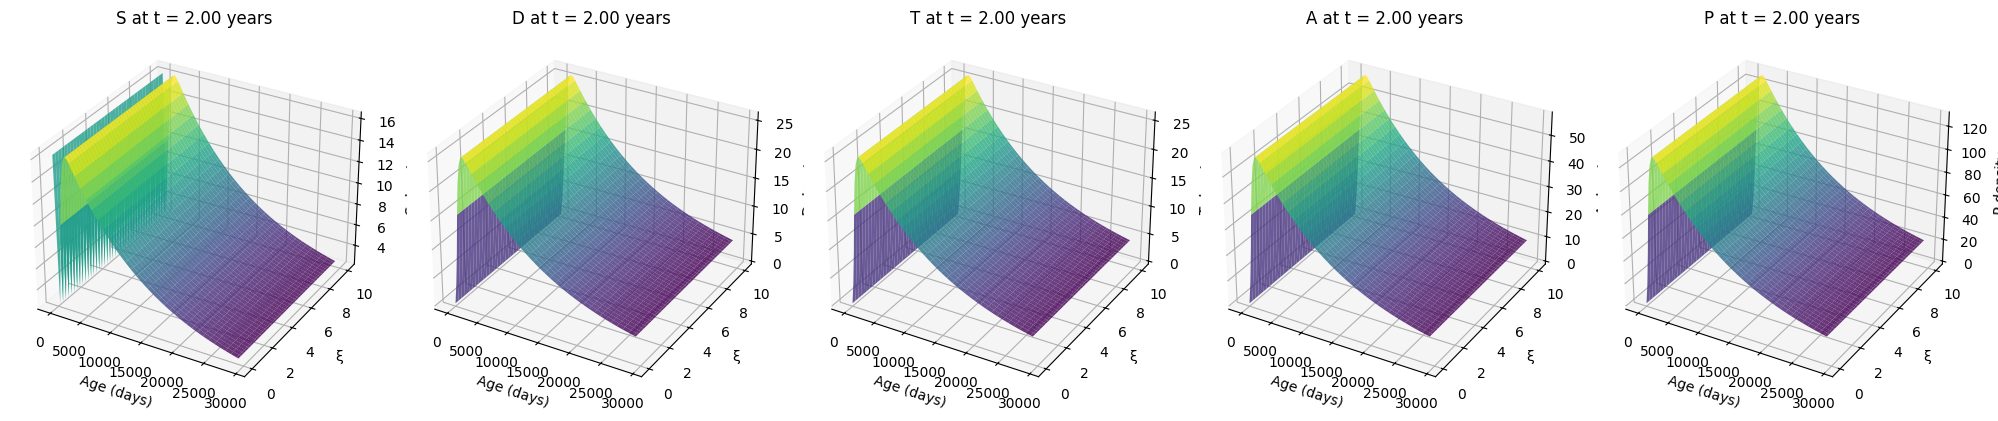

2. Heatmaps at the final time step:


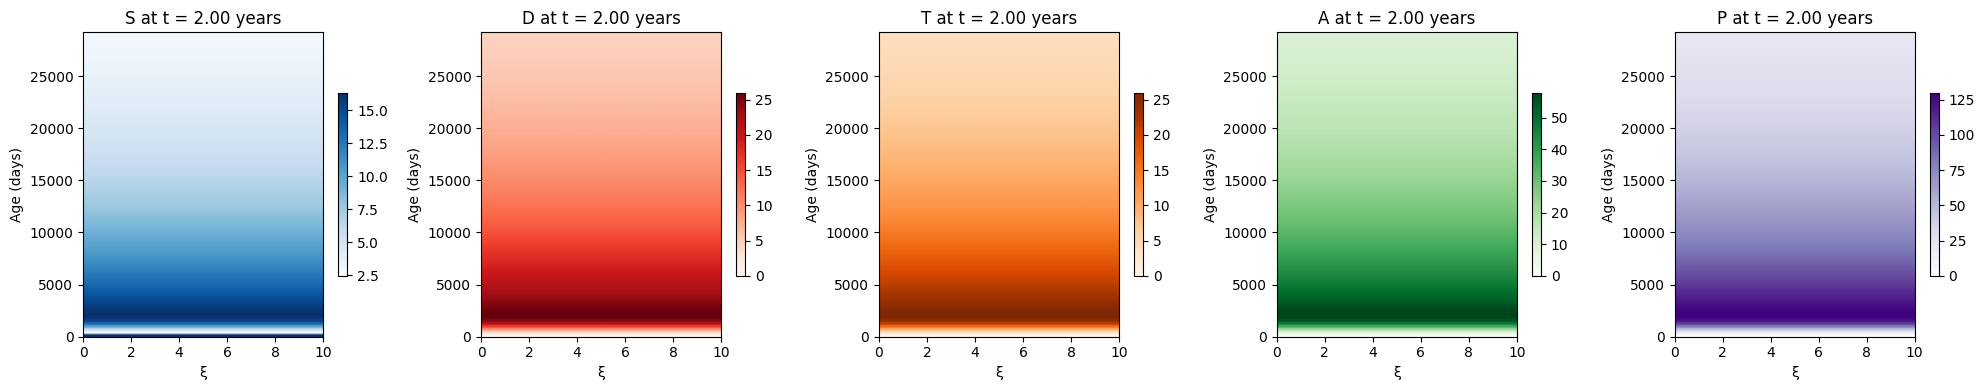

In [4]:
# ====================  VISUALIZATIONS ====================

print("\n Preparing visualizations...")

# Loading data for visualization
data = np.load("malaria_simulation_results.npz")
U_full = data['U_snaps']
times = data['times']
age_grid = data['age_grid']
xi_grid = data['xi_grid']

print(f" Loaded data: U_full{U_full.shape}")

# Grid for surface plots
A, X = np.meshgrid(age_grid, xi_grid, indexing="ij")  # (Na_pts, Nx)

# ------------------------------------------------------
# 1) Surface plots of the 5 components on a single row
# ------------------------------------------------------
def plot_surfaces_at_time(t_index):
    """3D surface plots for the 5 components at a given time"""
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={"projection": "3d"})
    comps = ["S", "D", "T", "A", "P"]

    for j in range(5):
        ax = axes[j]
        U_slice = U_full[t_index, :, :, j]  # (Na, Nx)
        surf = ax.plot_surface(A, X, U_slice, cmap="viridis", alpha=0.8)
        ax.set_title(f"{comps[j]} at t = {times[t_index]/days_per_year:.2f} years")
        ax.set_xlabel("Age (days)")
        ax.set_ylabel("ξ")
        ax.set_zlabel(f"{comps[j]} density")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------
# 2) Heatmaps of the 5 components on a single row
# ------------------------------------------------------
def plot_heatmaps_at_time(t_index):
    """2D heatmaps for the 5 components at a given time"""
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    comps = ["S", "D", "T", "A", "P"]
    cmaps = ["Blues", "Reds", "Oranges", "Greens", "Purples"]

    for j in range(5):
        ax = axes[j]
        U_slice = U_full[t_index, :, :, j]  # (Na, Nx)
        im = ax.imshow(U_slice, aspect="auto", origin="lower",
                       extent=[xi_grid[0], xi_grid[-1], age_grid[0], age_grid[-1]],
                       cmap=cmaps[j])
        ax.set_title(f"{comps[j]} at t = {times[t_index]/days_per_year:.2f} years")
        ax.set_xlabel("ξ")
        ax.set_ylabel("Age (days)")
        plt.colorbar(im, ax=ax, shrink=0.6)

    plt.tight_layout()
    plt.show()


# ====================  VISUALIZATION EXECUTION ====================
print(" Available times:")
for i, t in enumerate(times):
    print(f"  Index {i:3d}: {t/days_per_year:.3f} years")
print("\n Generating visualizations...")

# Visualization at final time
print("1. Surface plots at the final time step:")
plot_surfaces_at_time(-1)

print("2. Heatmaps at the final time step:")
plot_heatmaps_at_time(-1)

1. Surface plots at the initial time step:


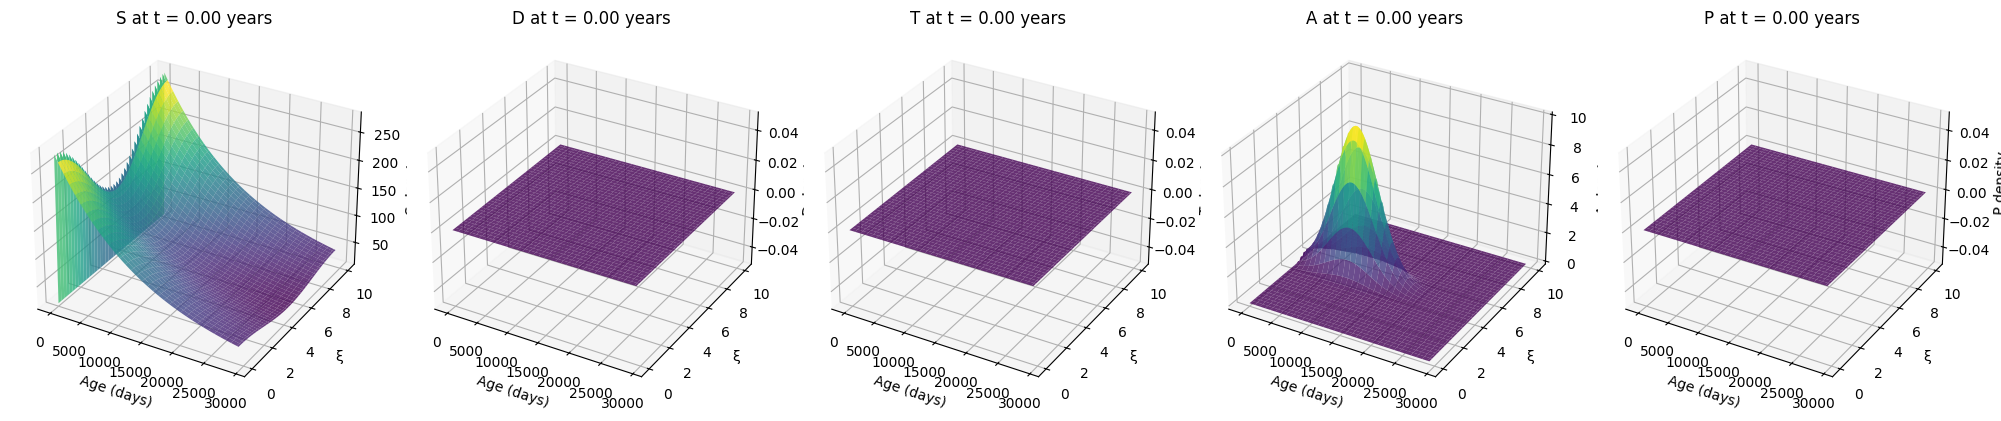

2. Heatmaps at the initial time step:


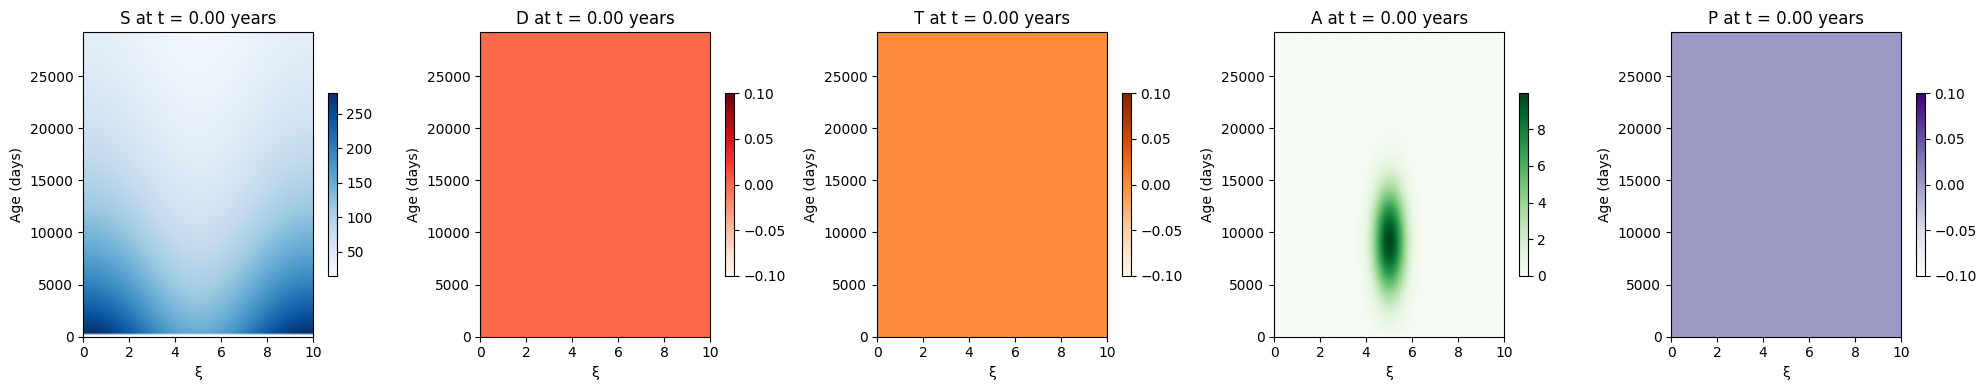

In [ ]:
print("1. Surface plots at the initial time step:")
plot_surfaces_at_time(0)

print("2. Heatmaps at the initial time step:")
plot_heatmaps_at_time(0)

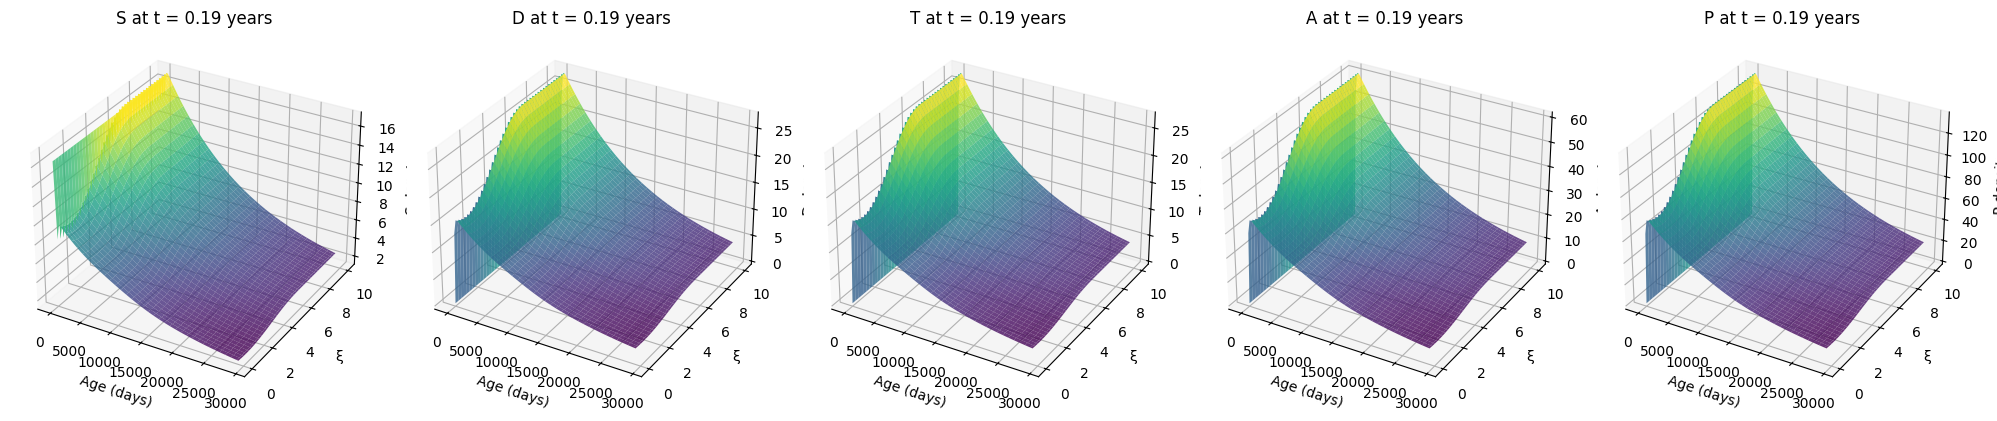

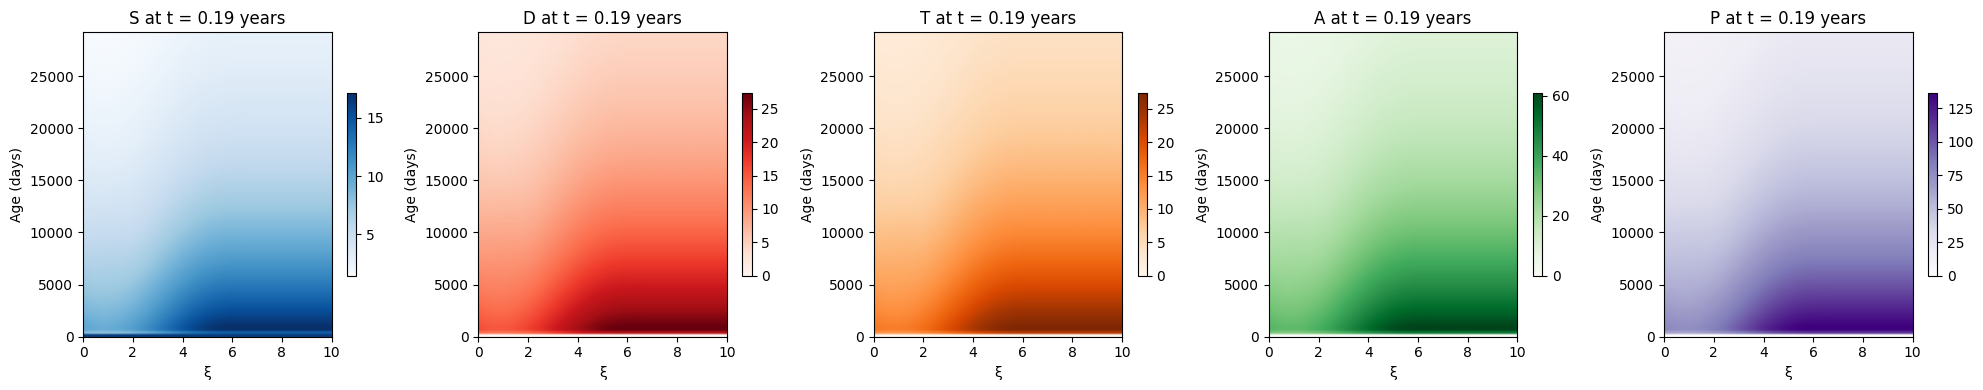

In [ ]:
plot_surfaces_at_time(10)
plot_heatmaps_at_time(10)

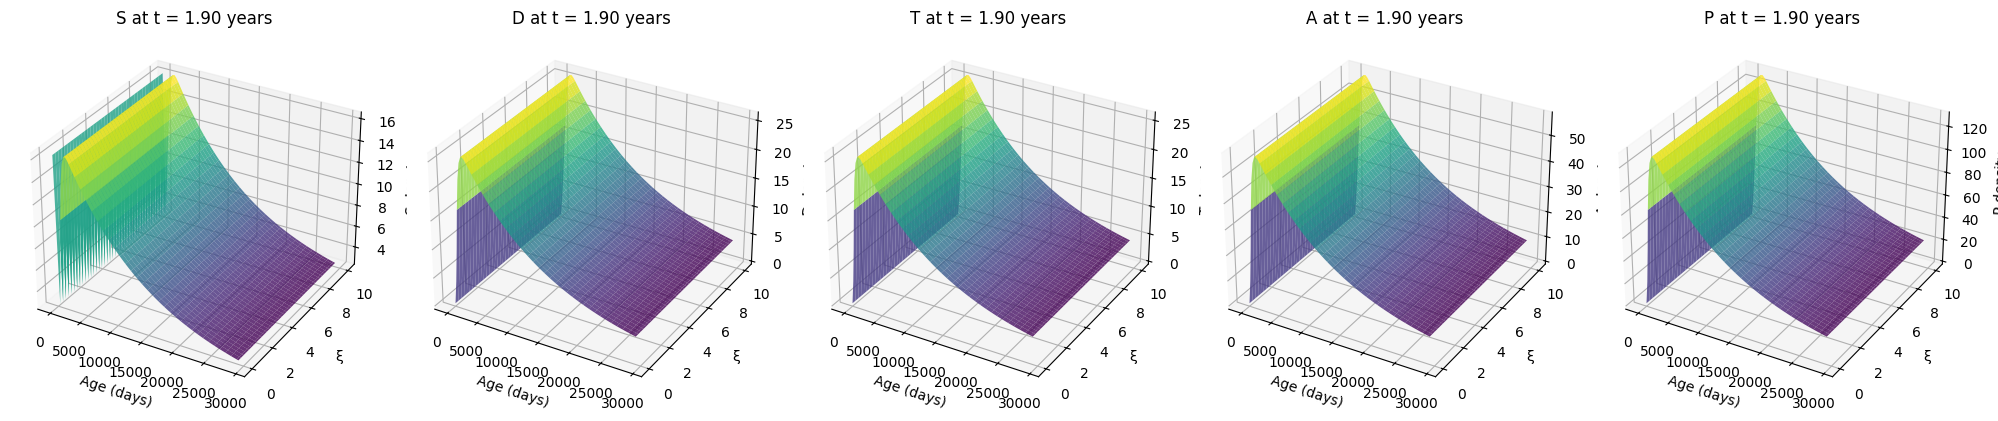

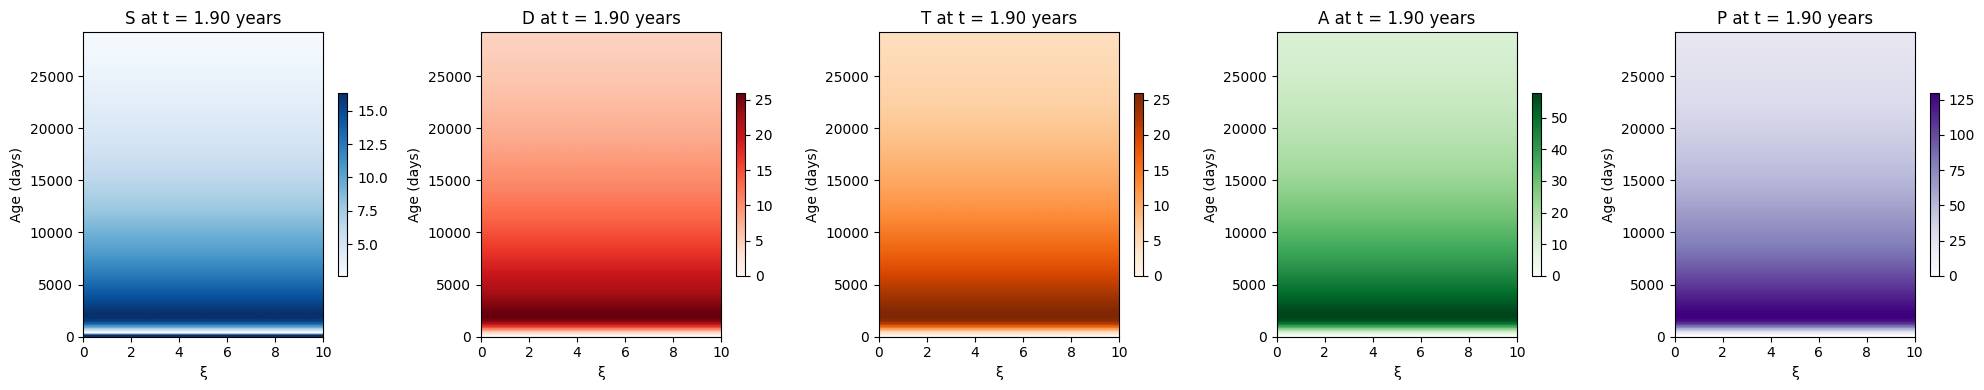

In [ ]:
plot_surfaces_at_time(100)
plot_heatmaps_at_time(100)

## Article-Oriented Visualizations

The following figures provide publication-style visualizations of the numerical solution. They are intended to illustrate the spatio-temporal behavior of the five epidemiological compartments and to support the discussion in the article.

## Structured Surface Plots for the Article

The next cells generate a more compact and article-friendly visualization layout, with multiple compartment surfaces arranged in a common grid for easier comparison across states and time snapshots.

In [ ]:
# ------------------------------------------------------
# New version: 3 rows × 2 columns
# ------------------------------------------------------
def plot_surfaces_at_time_grid(t_index):
    """
    Displays the 5 components (S, D, T, A, P) as 3D surfaces
    arranged on a 3x2 grid (more readable than placing everything on a single row).
    """
    from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection
    comps = ["S", "D", "T", "A", "P"]

    fig, axes = plt.subplots(2, 3, figsize=(9, 6), subplot_kw={"projection": "3d"})
    axes = axes.flatten()  # transforms the grid into a list for easier indexing

    for j, comp in enumerate(comps):
        ax = axes[j]
        U_slice = U_full[t_index, :, :, j]  # (Na, Nx)

        surf = ax.plot_surface(A, X, U_slice, cmap="viridis", alpha=0.9, linewidth=0)
        ax.set_title(f"{comp} at t = {times[t_index]/days_per_year:.2f} years", fontsize=10)
        ax.set_xlabel("Age (days)", fontsize=9)
        ax.set_ylabel("Exposure ξ", fontsize=9)
        ax.set_zlabel("Density", fontsize=9)
        ax.tick_params(axis='both', which='major', labelsize=8)

    # Remove the last empty subplot (6th slot)
    fig.delaxes(axes[-1])

    # Global adjustment
    # fig.suptitle(f"System components at t = {times[t_index]/days_per_year:.2f} years", fontsize=14, y=0.93)
    plt.tight_layout()
    plt.subplots_adjust(left=0, top=0.90, wspace=0.5, hspace=0.2)
    plt.show()

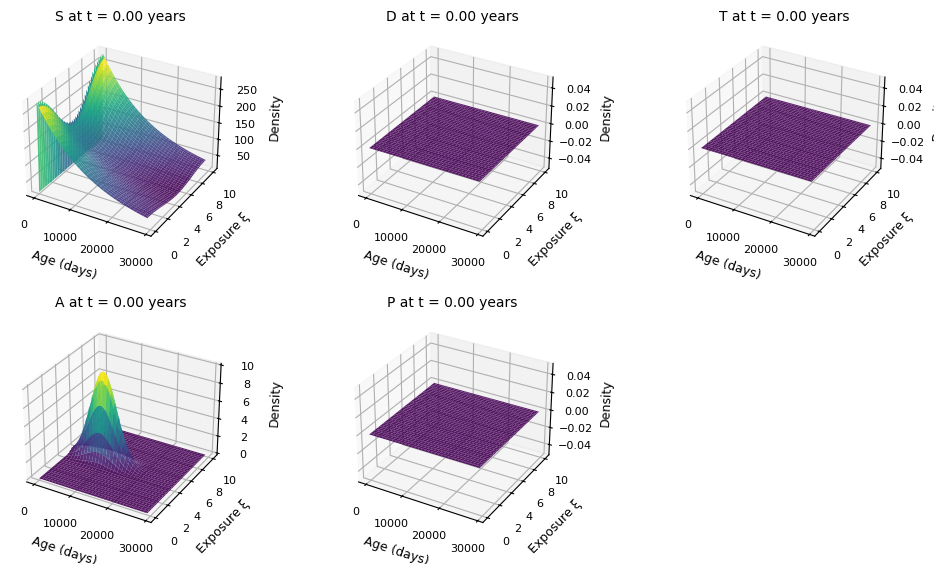

In [ ]:
plot_surfaces_at_time_grid(0)

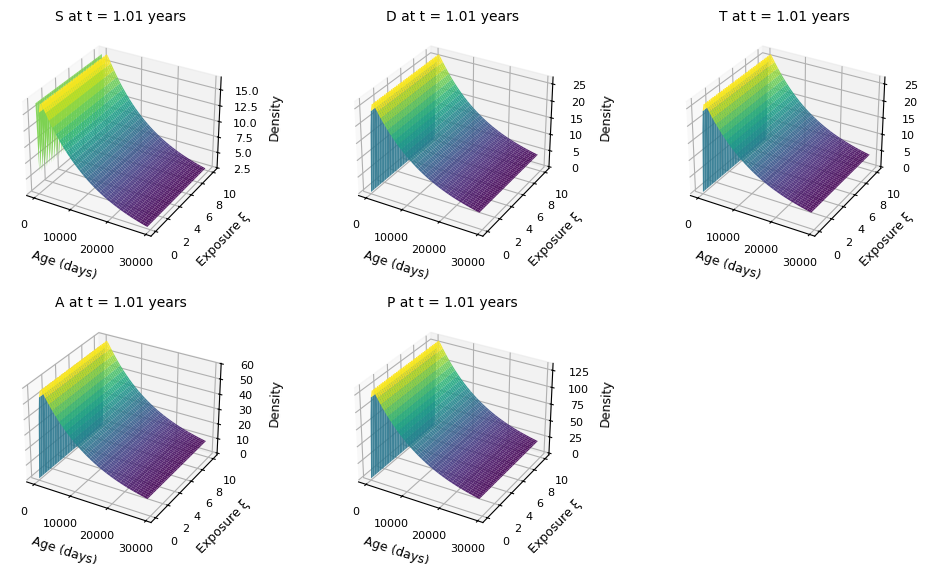

In [ ]:
plot_surfaces_at_time_grid(53)

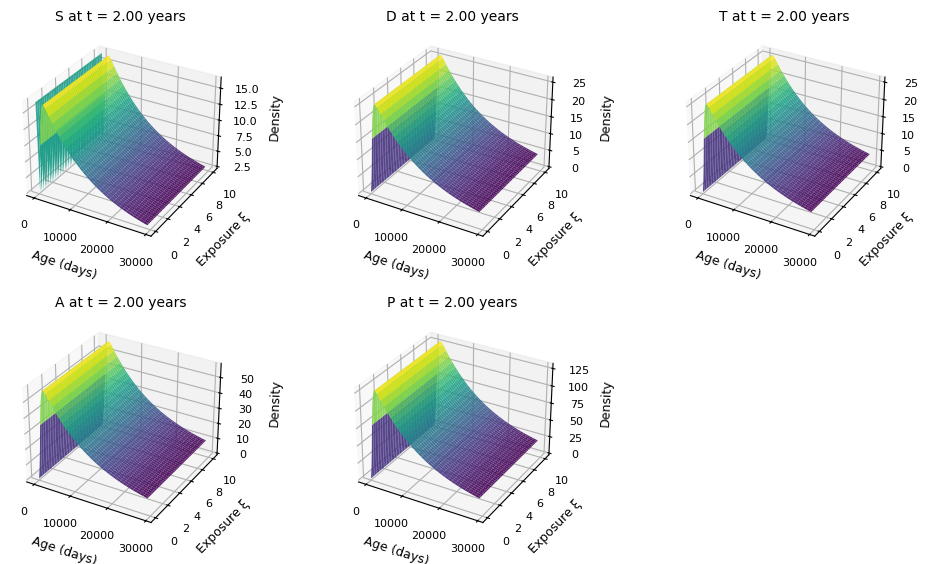

In [ ]:
plot_surfaces_at_time_grid(105)